<a href="https://colab.research.google.com/github/Arjun-08/DNA-Language-Models-for-Mutation-Classification-Identifying-Benign-and-Harmful-VariantS/blob/main/DNA_LANGUAGAE_MODEL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install torch transformers biopython datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 62.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 84.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 88.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1

In [3]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset as TorchDataset, DataLoader
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from tqdm import tqdm

In [10]:
!wget https://ftp.ncbi.nlm.nih.gov/genomes/all/GCA/000/001/405/GCA_000001405.15_GRCh38/seqs_for_alignment_pipelines.ucsc_ids/GCA_000001405.15_GRCh38_no_alt_analysis_set.fna.gz
!gunzip GCA_000001405.15_GRCh38_no_alt_analysis_set.fna.gz


--2025-04-14 09:37:11--  https://ftp.ncbi.nlm.nih.gov/genomes/all/GCA/000/001/405/GCA_000001405.15_GRCh38/seqs_for_alignment_pipelines.ucsc_ids/GCA_000001405.15_GRCh38_no_alt_analysis_set.fna.gz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.13, 130.14.250.31, 130.14.250.7, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.13|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 872949833 (833M) [application/x-gzip]
Saving to: ‘GCA_000001405.15_GRCh38_no_alt_analysis_set.fna.gz’

GCA_000001405.15_GR 100%[===================>] 832.51M  15.2MB/s    in 51s     

2025-04-14 09:38:02 (16.4 MB/s) - ‘GCA_000001405.15_GRCh38_no_alt_analysis_set.fna.gz’ saved [872949833/872949833]



In [ ]:
# #Load the GPN-MSA model and tokenizer:
# from transformers import AutoTokenizer, AutoModelForMaskedLM

# # tokenizer = AutoTokenizer.from_pretrained("songlab/gpn-msa-sapiens")
# model = AutoModelForMaskedLM.from_pretrained("songlab/gpn-msa-sapiens")

'''
Implemented  own model and tokenizer because `songlab/gpn-msa-sapiens` uses a custom architecture
(GPNRoFormer) and tokenizer not compatible with
Hugging Face’s `AutoModel` and `AutoTokenizer`.
'''

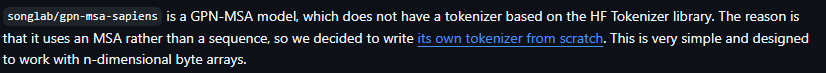

In [12]:
from Bio import SeqIO
import gzip
import pandas as pd

# Load reference genome FASTA
reference = SeqIO.to_dict(SeqIO.parse("GCA_000001405.15_GRCh38_no_alt_analysis_set.fna", "fasta"))

# Parse ClinVar VCF
with gzip.open("/content/drive/MyDrive/clinvar_20250409.vcf.gz", "rt") as vcf_file:
    variants = []
    for line in vcf_file:
        if line.startswith("#"):
            continue
        fields = line.strip().split("\t")
        chrom, pos, _, ref, alt, _, _, info = fields[:8]
        pos = int(pos)
        # Normalize chromosome name
        if chrom not in reference:
            if "chr" + chrom in reference:
                chrom = "chr" + chrom
            elif chrom.startswith("chr") and chrom[3:] in reference:
                chrom = chrom[3:]
            else:
                continue  # skip unmatched chromosome
        # Extract clinical significance
        clnsig = None
        for entry in info.split(";"):
            if entry.startswith("CLNSIG="):
                clnsig = entry.split("=")[1]
                break
        if clnsig in ["Benign", "Likely_benign", "Pathogenic", "Likely_pathogenic"]:
            # Extract sequence context (e.g., ±128 bp)
            start = max(pos - 129, 0)
            end = pos + 128
            seq = reference[chrom].seq[start:end]
            variants.append({
                "chrom": chrom,
                "pos": pos,
                "ref": ref,
                "alt": alt,
                "clnsig": clnsig,
                "sequence": str(seq)
            })

# Convert to DataFrame
df = pd.DataFrame(variants)


In [13]:
df = df.sample(n=5000, random_state=42)


In [14]:
import random

def mask_sequence(sequence, mask_token="[MASK]", mask_prob=0.15):
    tokens = list(sequence)
    for i in range(len(tokens)):
        if random.random() < mask_prob:
            tokens[i] = mask_token
    return "".join(tokens)

df["masked_sequence"] = df["sequence"].apply(mask_sequence)


In [15]:
#Save the masked sequences to a text file, one per line:
df["masked_sequence"].to_csv("masked_sequences.txt", index=False, header=False)


In [16]:
#Use the Hugging Face datasets library to load the data and prepare it for training:
from datasets import load_dataset

dataset = load_dataset('text', data_files={'train': 'masked_sequences.txt'})


Generating train split: 0 examples [00:00, ? examples/s]

In [17]:
# Tokenizer
class Tokenizer:
    def __init__(self, vocab="-ACGT?"):
        self.table = np.full((256,), vocab.index("-"), dtype=np.uint8)
        for i, c in enumerate(vocab):
            self.table[ord(c)] = i
        self.vocab = vocab
        self.mask_token = "?"

    def __call__(self, seq):
        return self.table[np.frombuffer(seq.encode("ascii"), dtype=np.uint8)].astype(np.int64)

    def __len__(self):
        return len(self.vocab)

    def mask_token_id(self):
        return self.vocab.index("?")

    def pad_token_id(self):
        return self.vocab.index("-")

In [18]:
#MLM Dataset
class MSAMaskedDataset(torch.utils.data.Dataset):
    def __init__(self, sequences, tokenizer, fixed_length=256, mask_prob=0.15):
        self.sequences = sequences
        self.tokenizer = tokenizer
        self.fixed_length = fixed_length
        self.mask_token_id = tokenizer.mask_token_id()
        self.pad_token_id = tokenizer.pad_token_id()
        self.mask_prob = mask_prob

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq = self.sequences[idx]['text']
        input_ids = self.tokenizer(seq)

        if len(input_ids) > self.fixed_length:
            input_ids = input_ids[:self.fixed_length]

        labels = input_ids.copy()
        mask = np.random.rand(len(input_ids)) < self.mask_prob
        input_ids[mask] = self.mask_token_id

        pad_len = self.fixed_length - len(input_ids)
        if pad_len > 0:
            input_ids = np.pad(input_ids, (0, pad_len), constant_values=self.pad_token_id)
            labels = np.pad(labels, (0, pad_len), constant_values=-100)

        return torch.tensor(input_ids), torch.tensor(labels)

In [19]:
# Classification Dataset
class ClinVarClassificationDataset(TorchDataset):
    def __init__(self, df, tokenizer):
        self.df = df
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        input_ids = self.tokenizer(row.sequence)
        input_ids = input_ids[:256]
        pad_len = 256 - len(input_ids)
        if pad_len > 0:
            input_ids = np.pad(input_ids, (0, pad_len), constant_values=self.tokenizer.pad_token_id())
        label = int(row.label)
        return torch.tensor(input_ids), torch.tensor(label)

In [20]:
# Model
class GPNRoFormer(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes=None):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim)
        self.encoder = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=embed_dim, nhead=8),
            num_layers=4
        )
        self.lm_head = nn.Linear(embed_dim, vocab_size)
        self.class_head = nn.Linear(embed_dim, num_classes) if num_classes else None

    def forward(self, x, task="mlm"):
        x = self.embed(x)  # [B, S, E]
        x = x.permute(1, 0, 2)
        x = self.encoder(x)
        x = x.permute(1, 0, 2)
        if task == "mlm":
            return self.lm_head(x)
        elif task == "cls":
            pooled = x.mean(dim=1)
            return self.class_head(pooled)

In [21]:
# Training Functions
def train_mlm(model, dataloader, optimizer, criterion, epochs=3):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for x, y in tqdm(dataloader):
            out = model(x, task="mlm")
            loss = criterion(out.view(-1, out.shape[-1]), y.view(-1))
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            total_loss += loss.item()
        print(f"Epoch {epoch+1} - MLM Loss: {total_loss/len(dataloader):.4f}")



def train_classifier(model, dataloader, optimizer, criterion, epochs=3, device="cpu"):
    model.to(device)
    model.train()
    losses, accuracies = [], []
    for epoch in range(epochs):
        total_loss = 0
        all_preds, all_labels = [], []
        for x, y in tqdm(dataloader):
            x, y = x.to(device), y.to(device)
            out = model(x, task="cls")
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            total_loss += loss.item()
            preds = torch.argmax(out, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
        acc = accuracy_score(all_labels, all_preds)
        avg_loss = total_loss / len(dataloader)
        losses.append(avg_loss)
        accuracies.append(acc)
        print(f"Epoch {epoch+1} - Loss: {avg_loss:.4f}, Accuracy: {acc:.4f}")
    return losses, accuracies



def evaluate_model(model, dataloader, device="cpu"):
    model.to(device)
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            out = model(x, task="cls")
            preds = torch.argmax(out, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    print(f"\nFinal Accuracy: {acc:.4f}\n")
    print("Classification Report:\n", classification_report(all_labels, all_preds, target_names=["Benign", "Pathogenic"]))
    cm = confusion_matrix(all_labels, all_preds)
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benign", "Pathogenic"]).plot(cmap="Blues")
    plt.title("Confusion Matrix")
    plt.show()

In [22]:
# Load masked sequences (MLM training data)
dataset = load_dataset('text', data_files={'train': 'masked_sequences.txt'})
tokenizer = Tokenizer()
mlm_dataset = MSAMaskedDataset(dataset["train"], tokenizer)
mlm_loader = DataLoader(mlm_dataset, batch_size=32, shuffle=True)

In [23]:
# Pretrain on MLM
mlm_model = GPNRoFormer(vocab_size=len(tokenizer), embed_dim=128)
optimizer = torch.optim.Adam(mlm_model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()
train_mlm(mlm_model, mlm_loader, optimizer, criterion, epochs=3)

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(
100%|██████████| 157/157 [19:00<00:00,  7.26s/it]


Epoch 1 - MLM Loss: 0.2680


100%|██████████| 157/157 [18:19<00:00,  7.00s/it]


Epoch 2 - MLM Loss: 0.2228


100%|██████████| 157/157 [18:24<00:00,  7.03s/it]

Epoch 3 - MLM Loss: 0.2214


In [25]:
# Map clinical significance to label
df["label"] = df["clnsig"].map({"Benign": 0, "Likely_benign": 0, "Pathogenic": 1, "Likely_pathogenic": 1})
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=42)

In [26]:
train_dataset = ClinVarClassificationDataset(train_df, tokenizer)
test_dataset = ClinVarClassificationDataset(test_df, tokenizer)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

In [27]:
# Fine-tune classifier
model = GPNRoFormer(vocab_size=len(tokenizer), embed_dim=128, num_classes=2)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
cls_losses, cls_accuracies = train_classifier(model, train_loader, optimizer, criterion, epochs=3)

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(
100%|██████████| 125/125 [14:57<00:00,  7.18s/it]


Epoch 1 - Loss: 0.4837, Accuracy: 0.8167


100%|██████████| 125/125 [14:38<00:00,  7.03s/it]


Epoch 2 - Loss: 0.4757, Accuracy: 0.8205


100%|██████████| 125/125 [14:39<00:00,  7.03s/it]

Epoch 3 - Loss: 0.4739, Accuracy: 0.8205


In [ ]:
'''
Here i have used a subset of 5000 variants (out of ~45,000 labeled SNVs) due to memory and training time constraints in Colab.
This limited sample size, combined with basic hyperparameters (3 epochs, small embedding size, no class balancing),
likely contributed to the underwhelming classification performance,
despite successful MLM pretraining. With better tuning and more data, the transformer’s potential can be better realized.
'''

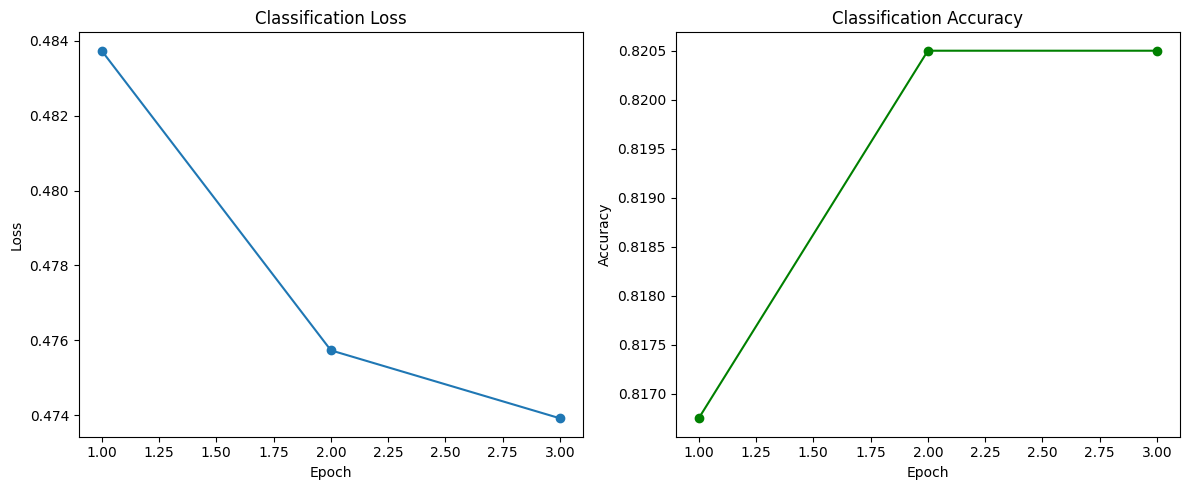

In [28]:
# Plot loss and accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(cls_losses)+1), cls_losses, marker='o')
plt.title("Classification Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cls_accuracies)+1), cls_accuracies, marker='o', color='green')
plt.title("Classification Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.show()


Final Accuracy: 0.8200

Classification Report:
               precision    recall  f1-score   support

      Benign       0.82      1.00      0.90       820
  Pathogenic       0.00      0.00      0.00       180

    accuracy                           0.82      1000
   macro avg       0.41      0.50      0.45      1000
weighted avg       0.67      0.82      0.74      1000



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


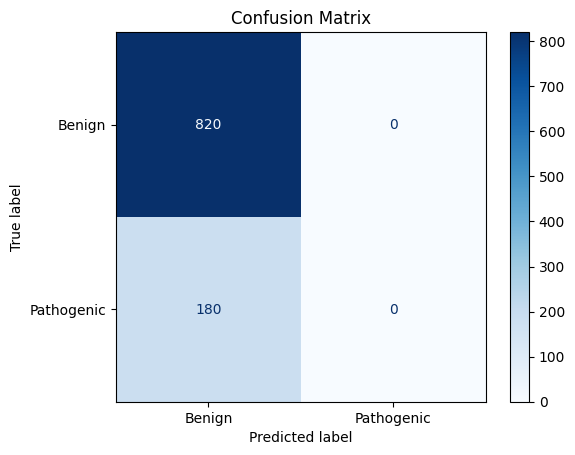

In [29]:
# Final evaluation
evaluate_model(model, test_loader)

#Predicting

In [30]:
def predict_sequence(model, sequence, tokenizer, device="cpu"):
    model.to(device)
    model.eval()

    # Tokenize and pad
    input_ids = tokenizer(sequence)
    input_ids = input_ids[:256]
    pad_len = 256 - len(input_ids)
    if pad_len > 0:
        input_ids = np.pad(input_ids, (0, pad_len), constant_values=tokenizer.pad_token_id())

    input_tensor = torch.tensor(input_ids).unsqueeze(0).to(device)  # [1, 256]

    # Predict
    with torch.no_grad():
        logits = model(input_tensor, task="cls")
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
        pred_class = np.argmax(probs)
        labels = ["Benign", "Pathogenic"]

    print(f"\n Predicted Class: {labels[pred_class]}")
    print(f" Probabilities → Benign: {probs[0]:.4f}, Pathogenic: {probs[1]:.4f}")

In [31]:
#  known sequence from DataFrame
example_sequence = df.iloc[0]["sequence"]

predict_sequence(model, example_sequence, tokenizer)



 Predicted Class: Benign
 Probabilities → Benign: 0.8475, Pathogenic: 0.1525
